<a href="{{ colab_base_laboratorios }}/Laboratorio_01_pinguinos_v2.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


##LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import f_oneway

##DATASET PINGUINOS.

In [ ]:
df = sns.load_dataset('penguins')
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


##FASE 1
###Parte A - Observación inicial.
1.) ¿Cuántas filas y columnas tiene el dataset?\
Rta//: Este dataset cuenta con 344 filas y 7 columnas, las cuales son: species, island, bill_length, bill_depth, flipper_length, body_mass y sex.\
2.) ¿Qué variables son numéricas y cuáles categóricas?\
Rta//: Las variables bill_length, bill_depth, flipper_length y body_mass son numéricas de tipo float64. Las otras variables: species, island y sex son de tipo object (categóricas).\
3.) ¿Cuántos valores faltantes hay por columna?\
Rta//: Generando un código para contar los valores faltantes en cada variable, tenemos que:

In [ ]:
pinguinos = list(df.columns)
valores_faltantes = []

for i in range(len(pinguinos)):
  valores_faltantes.append(df[pinguinos[i]].isna().sum())

print(np.int64(valores_faltantes))

[ 0  0  2  2  2  2 11]


Es decir que tenemos 0 valores faltantes para species, 0 valores faltantes para island, 2 valores faltantes para bill_length, 2 valores faltantes para bill_depth, 2 valores faltantes para flipper_length, 2 valores faltantes para body_mass y 11 valores faltantes para sex.\
4.) ¿Existen filas duplicadas?\
Rta//: Para esto crearemos un código con el cual identificaremos si existen filas duplicadas, por lo que:

In [ ]:
filas_duplicadas = df.duplicated().sum()
print(filas_duplicadas)

0


Con esto podemos decir que no hay ninguna fila duplicada.\
5.) ¿Qué variables tienen baja cardinalidad?\
Rta//: Para esto, haciendo un código simple para determinar la cardinalidad de las variables, tenemos que:



In [ ]:
pinguinos = list(df.columns)
cardinalidad = []

for i in range(len(pinguinos)):
  cardinalidad.append(df[pinguinos[i]].nunique())

print(cardinalidad)

[3, 3, 164, 80, 55, 94, 2]


Como podemos ver en esta lista, la cardinalidad de cada componente está asociada a la respectiva variable del dataframe; por tanto, las variables con baja cardinalidad son: species, island y sex, con sus valores de 3, 3 y 2 respectivamente.

## PARTE B - Descripción

6.) Creando un código para determinar la media, mediana, desviación estándar y rango intercuartílico.

In [ ]:
variables_numericas = list(df.select_dtypes(include = "number").columns)
media, mediana, desv_estandar, ran_intercuartlico = [ ] , [ ] , [ ] , [ ]

for i in range(len(variables_numericas)):
  media.append(df[variables_numericas[i]].mean())
  mediana.append(df[variables_numericas[i]].median())
  desv_estandar.append(df[variables_numericas[i]].std())
  q1 = df[variables_numericas[i]].quantile(0.25)
  q3 = df[variables_numericas[i]].quantile(0.75)
  ran_intercuartlico.append(q3 - q1)

In [ ]:
print("Media:",np.round(media, 2))
print("Mediana:",mediana)
print("Desviacion estandar:",np.round(desv_estandar,2))
print("Rango intercuartilico:",np.round(ran_intercuartlico, 2))

Media: [  43.92   17.15  200.92 4201.75]
Mediana: [44.45, 17.3, 197.0, 4050.0]
Desviacion estandar: [  5.46   1.97  14.06 801.95]
Rango intercuartilico: [   9.27    3.1    23.   1200.  ]


Analizando los datos obtenidos, tenemos que:

###Bill_length:
*   Media = 43,92
*   Mediana = 44,45
*   Desviación estándar = 5,46
*   Rango intercuartílico = 9,27

###Bill_depth:
*   Media = 17,15
*   Mediana = 15,3
*   Desviación estándar = 1,97
*   Rango intercuartílico = 3,1

###Flipper_length:
*   Media = 200,92
*   Mediana = 197,0
*   Desviación estándar = 14,06
*   Rango intercuartílico = 23,0

###Body_mass
*   Media = 4201,75
*   Mediana = 4050,0
*   Desviación estándar = 801,95
*   Rango intercuartílico = 1200,0


7.) Para cada variable categórica, su conteo y porcentaje respectivo.





In [ ]:
variables_categoricas = list(df.select_dtypes(include = "object").columns)
conteo , porcentaje = [] , []

for i in range(len(variables_categoricas)):
  conteo.append(df[variables_categoricas[i]].value_counts(dropna = False))
  porcentaje.append(df[variables_categoricas[i]].value_counts(dropna = False, normalize = True)*100)

conteo = pd.DataFrame(conteo)
porcentaje = pd.DataFrame(porcentaje)

In [ ]:
conteo

,Adelie,Gentoo,Chinstrap,Biscoe,Dream,Torgersen,Male,Female,NaN
count,152.0,124.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN
count,NaN,NaN,NaN,168.0,124.0,52.0,NaN,NaN,NaN
count,NaN,NaN,NaN,NaN,NaN,NaN,168.0,165.0,11.0


In [ ]:
porcentaje

,Adelie,Gentoo,Chinstrap,Biscoe,Dream,Torgersen,Male,Female,NaN
proportion,44.186047,36.046512,19.767442,NaN,NaN,NaN,NaN,NaN,NaN
proportion,NaN,NaN,NaN,48.837209,36.046512,15.116279,NaN,NaN,NaN
proportion,NaN,NaN,NaN,NaN,NaN,NaN,48.837209,47.965116,3.197674


Como podemos ver en las dos tablas, tenemos el conteo y los porcentajes respectivos para las variables categóricas.\
8.) Tenemos 3 tablas cruzadas relevantes: species × island, species × sex, island × sex.

### specie × island


In [ ]:
species_island = pd.crosstab(df["species"], df["island"])
species_island

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


### specie × sex

In [ ]:
specie_sex = pd.crosstab(df["species"], df["sex"])
specie_sex

sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


### island × sex

In [ ]:
island_sex =  pd.crosstab(df["island"], df["sex"])
island_sex

sex,Female,Male
island,,
Biscoe,80,83
Dream,61,62
Torgersen,24,23


9.) Calculando las matrices de correlación entre las variables numéricas.


In [ ]:
matriz_corr = df[variables_numericas].corr(method = "pearson")
matriz_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Teniendo todas las tablas podemos ver el coeficiente de correlación, que es el valor fuera de la diagonal; en todos los valores se cumple que:
$$-1\leq r \leq 1$$

## Parte C - Visualización
10.) Gráficos de conteo para variables de baja cardinalidad.\
Las variables categóricas para este caso son: species, island y sex.

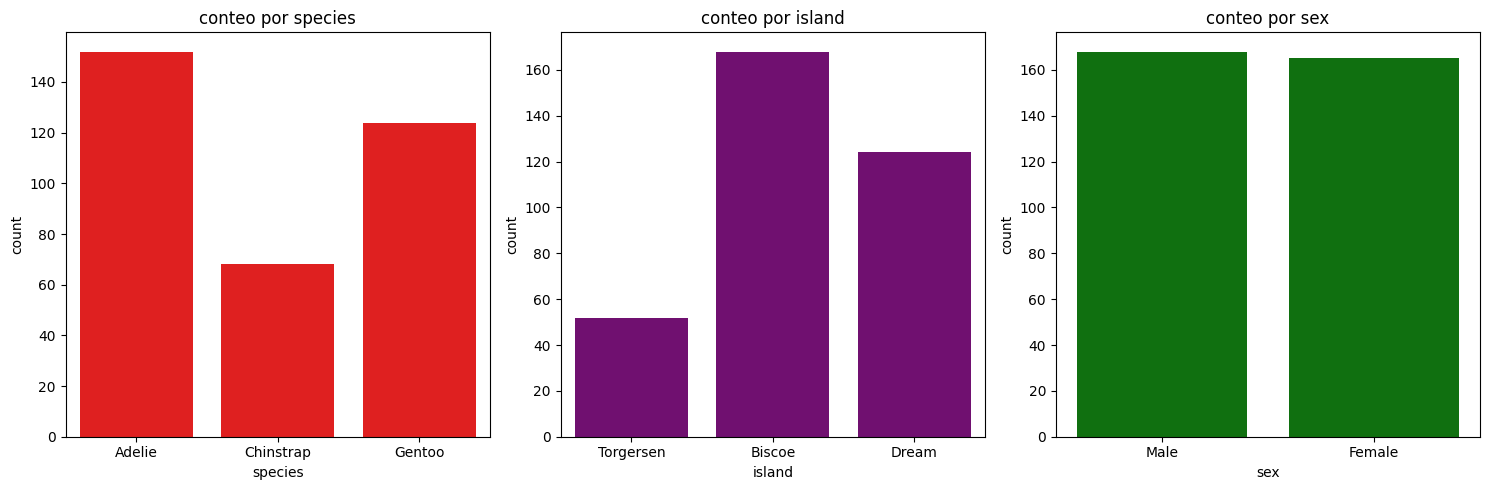

In [ ]:
fig , axes = plt.subplots(1,3, figsize = (15,5))

sns.countplot(x = "species", data = df, ax = axes[0], color = "red")
sns.countplot(x = "island", data = df, ax = axes[1], color = "purple")
sns.countplot(x = "sex", data = df, ax = axes[2], color = "green")

axes[0].set_title("conteo por species")
axes[1].set_title("conteo por island")
axes[2].set_title("conteo por sex")

plt.tight_layout()
plt.show()

11.) Histogramas para variables numéricas.


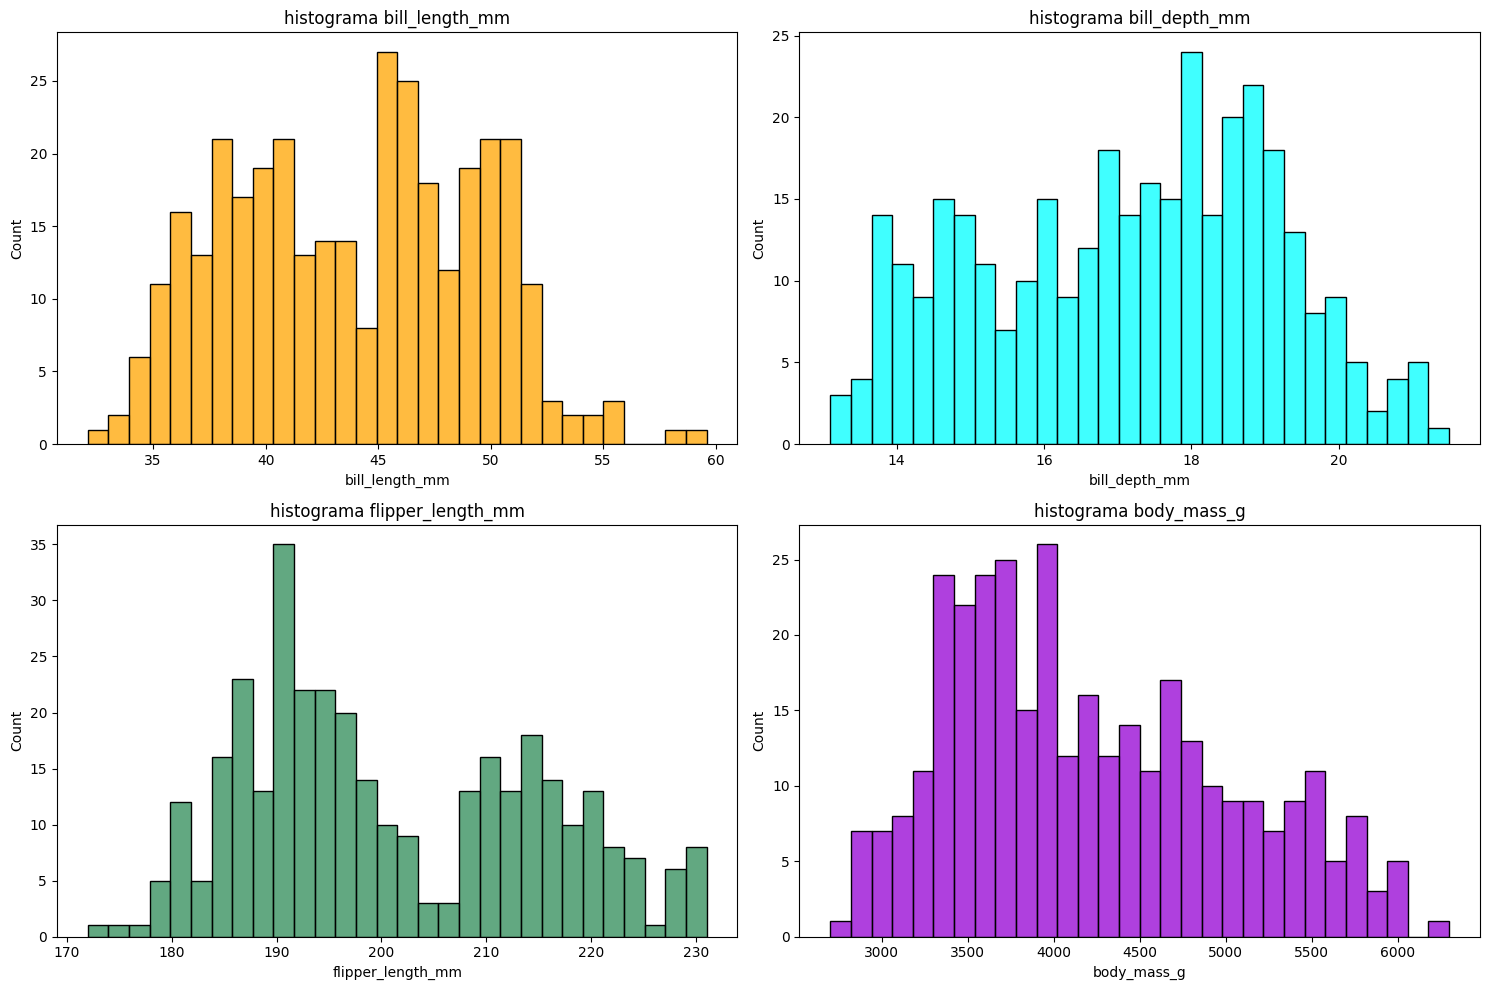

In [ ]:
fig , axes = plt.subplots(2,2, figsize = (15,10))

sns.histplot(x = "bill_length_mm", data = df, ax = axes[0,0] , bins = 30,color = "orange")
sns.histplot(x = "bill_depth_mm", data = df, ax = axes[0,1] , bins = 30 ,color = "aqua")
sns.histplot(x = "flipper_length_mm", data = df, ax = axes[1,0] , bins = 30, color = "seagreen")
sns.histplot(x = "body_mass_g", data = df, ax = axes[1,1] , bins = 30,color = "darkviolet")

axes[0,0].set_title("histograma bill_length_mm")
axes[0,1].set_title("histograma bill_depth_mm")
axes[1,0].set_title("histograma flipper_length_mm")
axes[1,1].set_title("histograma body_mass_g")

plt.tight_layout()
plt.show()

12.) Boxplots de una variable numérica por categoría.

###Body_mass × species

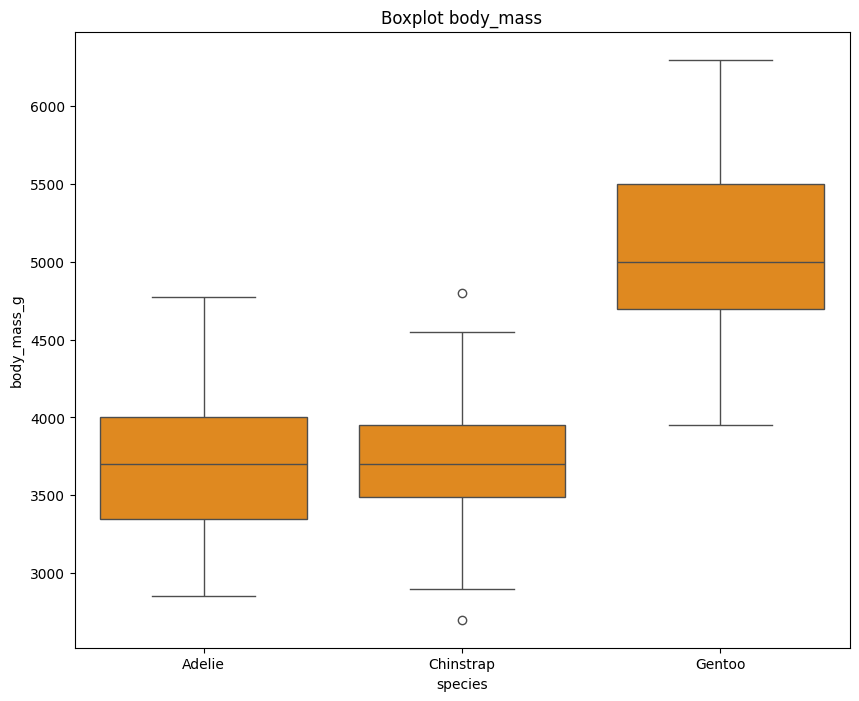

In [ ]:
plt.figure(figsize= (10,8))
sns.boxplot(x = "species",y = "body_mass_g", data = df, color = "darkorange")
plt.title("Boxplot body_mass")
plt.show()

###Body_mass × island

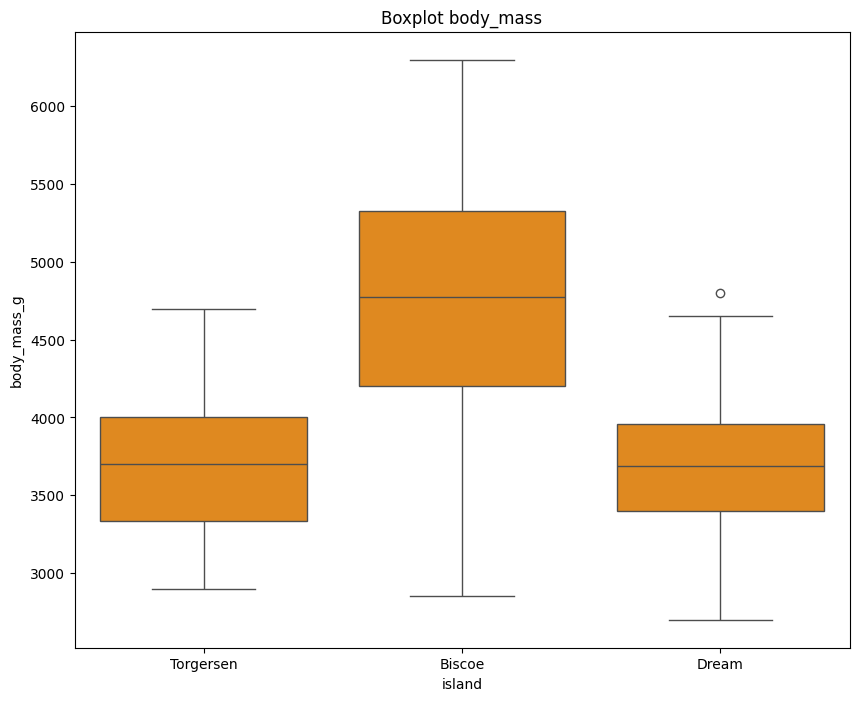

In [ ]:
plt.figure(figsize= (10,8))
sns.boxplot(x = "island",y = "body_mass_g", data = df, color = "darkorange")
plt.title("Boxplot body_mass")
plt.show()

###Body_mass × sex

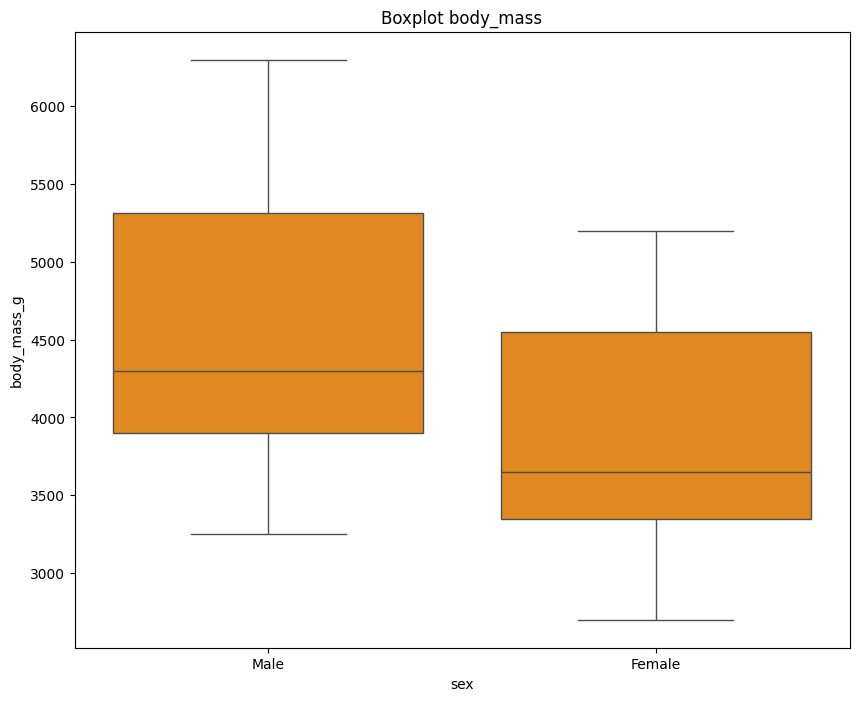

In [ ]:
plt.figure(figsize= (10,8))
sns.boxplot(x = "sex",y = "body_mass_g", data = df, color = "darkorange")
plt.title("Boxplot body_mass")
plt.show()


13.) Scatter entre bill_length × bill_depth para la categoría de island.


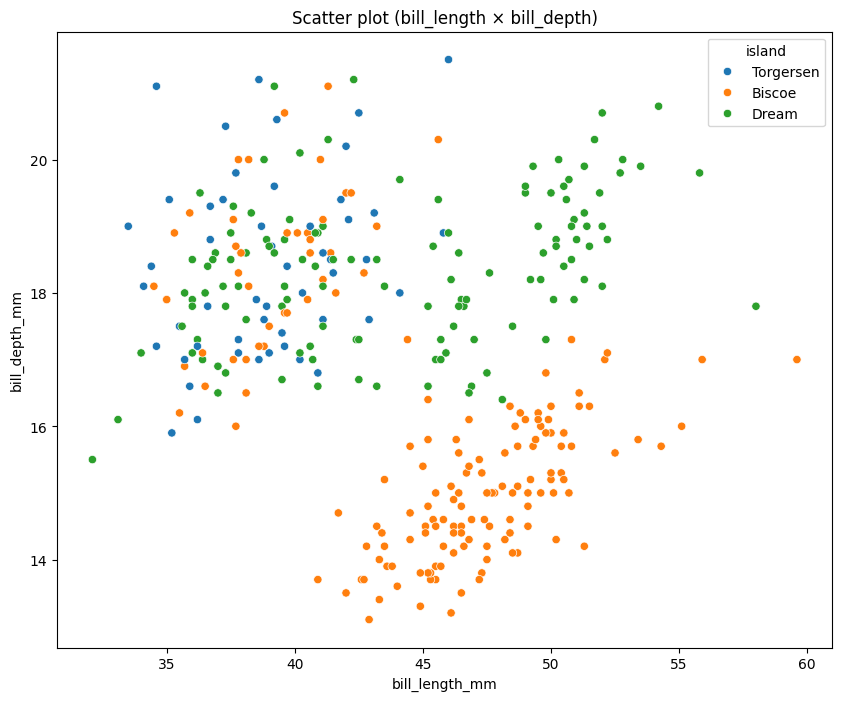

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df , x = "bill_length_mm", y = "bill_depth_mm", hue = "island")
plt.title("Scatter plot (bill_length × bill_depth)")
plt.show()

14.) Heatmap de correlación.



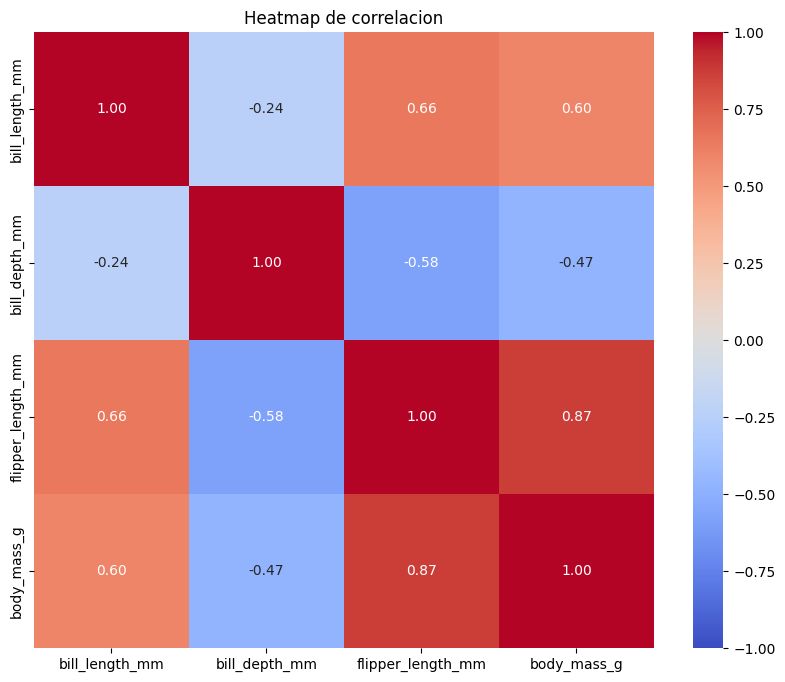

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(matriz_corr, annot = True , cmap = "coolwarm" , fmt= ".2f" , vmin = -1 ,vmax = 1)
plt.title("Heatmap de correlacion")
plt.show()

##Parte D - Hipótesis sin causalidad.
15.) Proponiendo al menos 3 hipotesis falseables basadas en los graficos, tenemos que:
1.   Bill_depth se asocia con bill_length.
2.   Boddy_mass difiere por island.
1.   Island se asocia con sex.

##Parte E - Pruebas estadísticas.
16.) Teniendo en cuenta las hipotesis planteadas tenemos que las pruebas adecuadas son: Pearson, ANOVA, χ². Respectivamente.
### 1. Bill_depth se asocia con bill_length:






In [ ]:
pearson = df[["bill_length_mm","bill_depth_mm"]].dropna()
r , valor_p1 = pearsonr(pearson["bill_length_mm"] , pearson["bill_depth_mm"])

###2. Boddy_mass difiere por island:

In [ ]:
biscoe = df[df["island"] == "Biscoe"]["body_mass_g"].dropna()
dream = df[df["island"] == "Dream"]["body_mass_g"].dropna()
torgersen = df[df["island"] == "Torgersen"]["body_mass_g"].dropna()

f_stat , valor_p2 = f_oneway(biscoe, dream, torgersen)

###3. Island se asocia con sex:

In [ ]:
tabla = pd.crosstab(df["island"], df["sex"])
chi2 , valor_p3 , _ ,  _ = chi2_contingency(tabla)

17.) Reporte estadístico y valor p.

In [ ]:
resultados_1 = (["bill_length ~ bill_depth", "Pearson" , r , valor_p1])
resultados_2 = (["body_mass ~ island", "ANOVA" , f_stat , valor_p2])
resultados_3 = (["island ~ sex", "χ²" , chi2 , valor_p3])
resultados = [resultados_1 , resultados_2 , resultados_3]

reporte = pd.DataFrame(resultados , columns= ["Hipótesis" , "Prueba" , "Estadístico" , "Valor p"])
reporte["Desición para (α=0.05)"] = reporte["Valor p"].apply(lambda p : "Rechaza H_o " if p < 0.05 else "No rechaza H_o")
reporte

,Hipótesis,Prueba,Estadístico,Valor p,Desición para (α=0.05)
0,bill_length ~ bill_depth,Pearson,-0.235053,1.119662e-05,Rechaza H_o
1,body_mass ~ island,ANOVA,110.007965,1.515129e-37,Rechaza H_o
2,island ~ sex,χ²,0.057599,9.716112e-01,No rechaza H_o


18.) Como podemos ver en la tabla anterior, rechazamos las dos primeras hipótesis (bill_length ~ bill_depth , body_mass ~ island ), en cambio, la que aceptamos es la ultima hipótesis (island ~ sex).

##Parte F - Conclusiones y reportes
19.) Mostrando las conclusiones en tres capas:
1.  Podemos observar, por medio de la matriz de correlación entre las variables numéricas, que algunas presentan correlación negativa y otras positiva; sin embargo, algunas tienden a acercarse a uno mientras que otras tienden a acercarse a cero.
2.  Para la gráfica de dispersión entre dos variables, teniendo en cuenta la variable categórica island, observamos una mayor concentración de puntos para Biscoe y Dream, mientras que para Torgersen tenemos una dispersión mucho más baja.
3.  Otras hipótesis para comprobar serían: sex se asocia con species, flipper_length difiere por species, bill_depth difiere por sex.

20). Preguntas para un investigador humano.


*   ¿Existe una razón ecológica o evolutiva conocida por la cual las especies Gentoo y Chinstrap se concentran cada una en una sola isla, mientras que Adelie está presente en las tres?
*  ¿La diferencia de peso corporal (body_mass_g) que se observa entre islas se debe realmente a condiciones ambientales distintas de cada isla, o es enteramente explicada por qué especies habitan cada una?


